**IMPORTING MODULES**

In [107]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, silhouette_score
import tensorflow
from tensorflow import keras

**READING DATASET**

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
df=pd.read_csv('/content/drive/MyDrive/breach_report (1).csv')
df

,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present,Web Description
0,American Healthcare Systems LLC dba Randolph H...,NC,Healthcare Provider,899,04-10-2024,Hacking/IT Incident,Email,No,NaN
1,The Epilepsy Foundation of Metro New York,NY,Healthcare Provider,3852,04-08-2024,Hacking/IT Incident,Network Server,No,NaN
2,Group Health Cooperative of South Central Wisc...,WI,Health Plan,533809,04-08-2024,Hacking/IT Incident,Network Server,No,NaN
3,Sleep Management Institute,OH,Healthcare Provider,500,04-05-2024,Hacking/IT Incident,Network Server,No,NaN
4,"Gaia Software, LLC",CO,Business Associate,56676,04-05-2024,Hacking/IT Incident,Network Server,Yes,NaN
...,...,...,...,...,...,...,...,...,...
908,The Energy Cooperative Group Benefits Plan,OH,Health Plan,875,04/21/2022,Hacking/IT Incident,Network Server,No,NaN
909,"Wayne Family Practice Associates, PC",GA,Healthcare Provider,5944,04/19/2022,Hacking/IT Incident,Network Server,No,NaN
910,"Fairfield County Implants and Periodontics, LLC",CT,Healthcare Provider,10502,04/19/2022,Hacking/IT Incident,Email,No,NaN
911,"Optima Dermatology Holdings, LLC",NH,Healthcare Provider,59872,04/18/2022,Hacking/IT Incident,Email,No,NaN


In [110]:
df['Type of Breach'].value_counts()

Type of Breach
Hacking/IT Incident               768
Unauthorized Access/Disclosure    116
Theft                              16
Loss                               10
Improper Disposal                   3
Name: count, dtype: int64

**UNDERSTANDING DATASET**

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Name of Covered Entity            913 non-null    object 
 1   State                             910 non-null    object 
 2   Covered Entity Type               912 non-null    object 
 3   Individuals Affected              913 non-null    int64  
 4   Breach Submission Date            913 non-null    object 
 5   Type of Breach                    913 non-null    object 
 6   Location of Breached Information  913 non-null    object 
 7   Business Associate Present        913 non-null    object 
 8   Web Description                   0 non-null      float64
dtypes: float64(1), int64(1), object(7)
memory usage: 64.3+ KB


In [112]:
df.shape

(913, 9)

In [113]:
df.dtypes

Name of Covered Entity               object
State                                object
Covered Entity Type                  object
Individuals Affected                  int64
Breach Submission Date               object
Type of Breach                       object
Location of Breached Information     object
Business Associate Present           object
Web Description                     float64
dtype: object

In [114]:
df.isna().sum()

Name of Covered Entity                0
State                                 3
Covered Entity Type                   1
Individuals Affected                  0
Breach Submission Date                0
Type of Breach                        0
Location of Breached Information      0
Business Associate Present            0
Web Description                     913
dtype: int64

In [115]:
df.drop('Web Description',axis=1,inplace=True)

In [116]:
df.dropna(inplace=True)
df.isna().sum()

Name of Covered Entity              0
State                               0
Covered Entity Type                 0
Individuals Affected                0
Breach Submission Date              0
Type of Breach                      0
Location of Breached Information    0
Business Associate Present          0
dtype: int64

In [117]:
df.head()

,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present
0,American Healthcare Systems LLC dba Randolph H...,NC,Healthcare Provider,899,04-10-2024,Hacking/IT Incident,Email,No
1,The Epilepsy Foundation of Metro New York,NY,Healthcare Provider,3852,04-08-2024,Hacking/IT Incident,Network Server,No
2,Group Health Cooperative of South Central Wisc...,WI,Health Plan,533809,04-08-2024,Hacking/IT Incident,Network Server,No
3,Sleep Management Institute,OH,Healthcare Provider,500,04-05-2024,Hacking/IT Incident,Network Server,No
4,"Gaia Software, LLC",CO,Business Associate,56676,04-05-2024,Hacking/IT Incident,Network Server,Yes


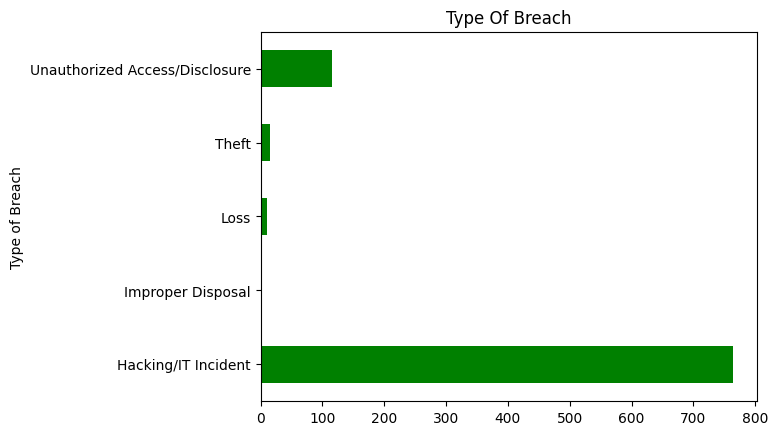

In [118]:
df.groupby('Type of Breach').size().plot(kind='barh',color='green')
plt.title('Type Of Breach')
plt.show()

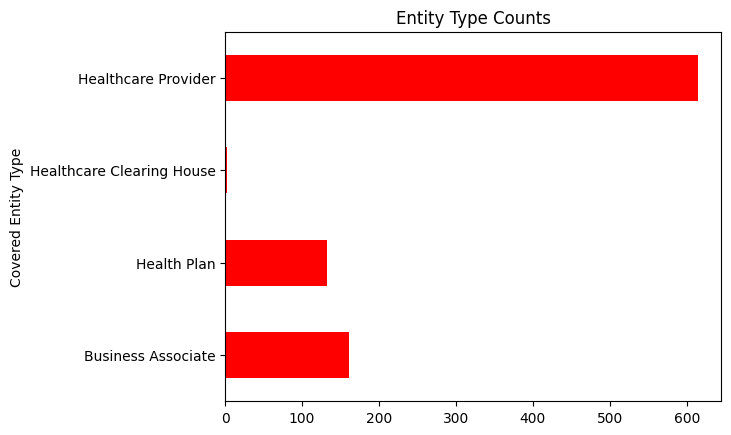

In [119]:
df.groupby('Covered Entity Type').size().plot(kind='barh',color='red')
plt.title('Entity Type Counts')
plt.show()

Text(45.7222222222222, 0.5, 'Type of Breach')

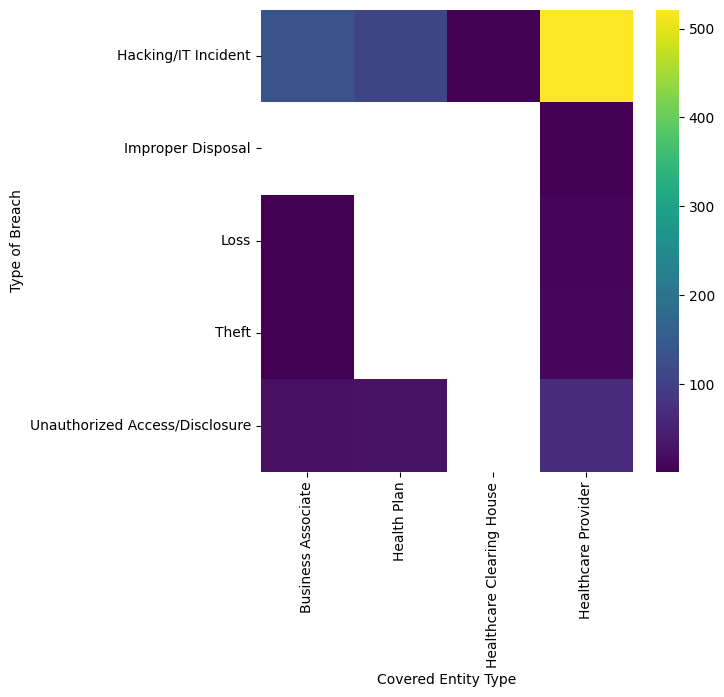

In [120]:
plt.subplots(figsize=(6, 6))
df_2dhist = pd.DataFrame({
    x_label: grp['Type of Breach'].value_counts()
    for x_label, grp in df.groupby('Covered Entity Type')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Covered Entity Type')
plt.ylabel('Type of Breach')

In [121]:
df['Type of Breach'].value_counts()

Type of Breach
Hacking/IT Incident               764
Unauthorized Access/Disclosure    116
Theft                              16
Loss                               10
Improper Disposal                   3
Name: count, dtype: int64

In [122]:
le=LabelEncoder()
df['Name of Covered Entity']=le.fit_transform(df['Name of Covered Entity'])
df['State']=le.fit_transform(df['State'])
df['Covered Entity Type']=le.fit_transform(df['Covered Entity Type'])
df['Individuals Affected']=le.fit_transform(df['Individuals Affected'])
df['Individuals Affected']=le.fit_transform(df['Individuals Affected'])
df['Breach Submission Date']=le.fit_transform(df['Breach Submission Date'])
df['Location of Breached Information']=le.fit_transform(df['Location of Breached Information'])
df['Business Associate Present']=le.fit_transform(df['Business Associate Present'])
df['Type of Breach']=le.fit_transform(df['Type of Breach'])

In [123]:
df

,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present
0,44,27,3,73,110,0,9,0
1,764,34,3,306,108,0,14,0
2,330,47,1,754,108,0,14,0
3,707,35,3,0,106,0,14,0
4,310,5,0,614,106,0,14,1
...,...,...,...,...,...,...,...,...
908,763,35,1,69,118,0,14,0
909,839,10,3,361,116,0,14,0
910,287,6,3,442,116,0,9,0
911,580,30,3,619,114,0,9,0


Text(0, 0.5, 'Hacking/IT Incident')

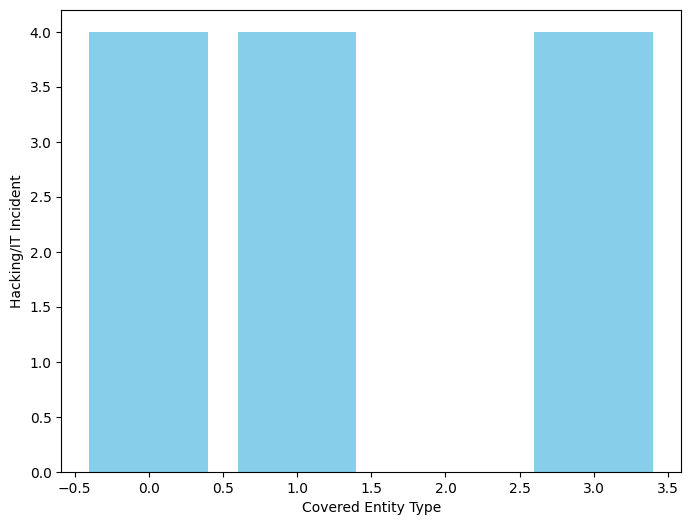

In [124]:
plt.figure(figsize=(8, 6))
plt.bar(df['Covered Entity Type'], df['Type of Breach'], color='skyblue')
plt.xlabel('Covered Entity Type')
plt.ylabel('Hacking/IT Incident')

**SPLITTING DATA**

In [125]:
X=df.drop('Type of Breach',axis=1)
Y=df['Type of Breach']
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state = 0)

In [126]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(636, 7)
(273, 7)
(636,)
(273,)


**SVM**

In [127]:
svm=SVC()
svm_model=svm.fit(x_train,y_train)
svm_pred=svm_model.predict(x_test)
accuracy_score(y_test,svm_pred)

0.8754578754578755

In [128]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       239
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        26

    accuracy                           0.88       273
   macro avg       0.22      0.25      0.23       273
weighted avg       0.77      0.88      0.82       273



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

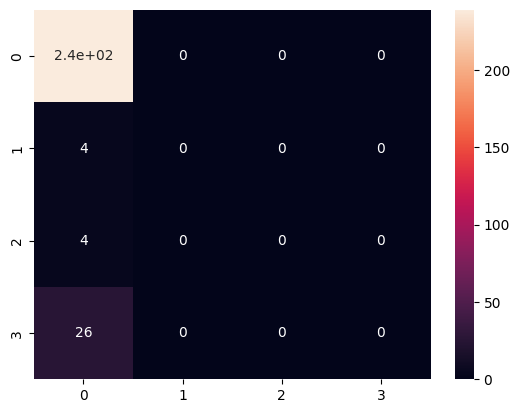

In [129]:
cm=confusion_matrix(y_test,svm_pred)
sns.heatmap(cm,annot=True)

**LDA**

In [130]:
lda=LinearDiscriminantAnalysis()
lda_model=lda.fit(df,Y)

In [131]:
x_train, x_test, y_train, y_test = train_test_split(df, Y, test_size=0.2, random_state=42)
x_test

,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present
870,721,35,3,140,175,0,14,1
440,224,10,0,637,254,0,16,1
342,297,10,0,691,323,0,14,1
740,396,10,1,247,337,0,14,0
790,481,16,3,510,282,0,14,0
...,...,...,...,...,...,...,...,...
582,555,34,3,0,162,0,14,0
873,701,19,0,784,163,0,14,1
446,15,27,0,434,250,0,9,1
791,279,34,1,351,282,0,14,1


Accuracy: 0.8626373626373627

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93       157
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        19

    accuracy                           0.86       182
   macro avg       0.17      0.20      0.19       182
weighted avg       0.74      0.86      0.80       182


Confusion Matrix:



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

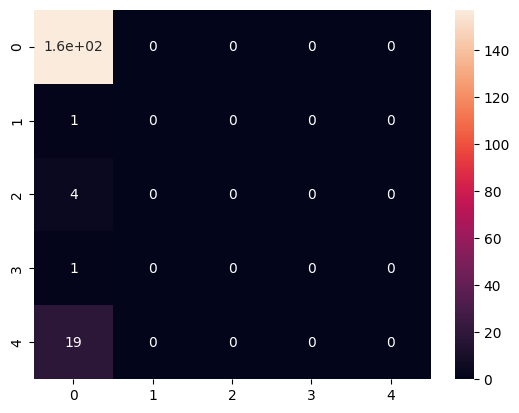

In [132]:
# Apply the model on the testing set
X_test_lda =  lda_model.transform(x_test)
y_pred = lda_model.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_rep)
print("\nConfusion Matrix:\n")
sns.heatmap(conf_matrix,annot=True)

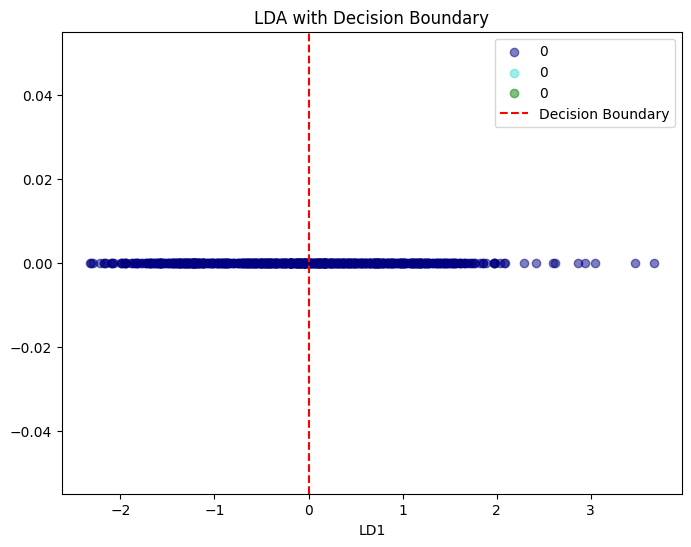

In [133]:
plt.figure(figsize=(8, 6))

# Plot points of class 0
plt.scatter(X_test_lda[y_pred == 0], np.zeros_like(X_test_lda[y_pred == 0]), color='navy', alpha=0.5, label=Y[0])

# Plot points of class 1
plt.scatter(X_test_lda[y_pred == 1], np.zeros_like(X_test_lda[y_pred == 1]), color='turquoise', alpha=0.5, label=Y[1])

#plot points of class 2
plt.scatter(X_test_lda[y_pred == 2], np.zeros_like(X_test_lda[y_pred == 2]), color='green', alpha=0.5, label=Y[2])


# Plot decision boundary
plt.axvline(x=0, color='r', linestyle='--', label='Decision Boundary')

plt.title('LDA with Decision Boundary')
plt.xlabel('LD1')
plt.ylabel('')

plt.legend()
plt.show()

**PARTIONING - KMEANS**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

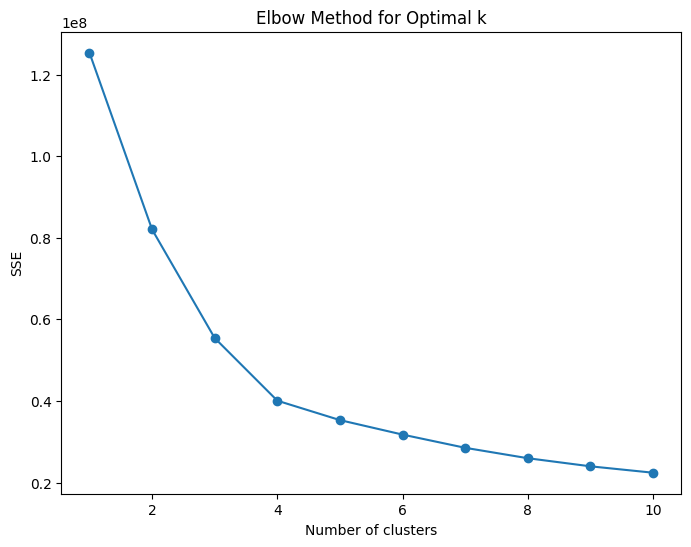

In [134]:
from sklearn.cluster import KMeans
def find_optimal_clusters(data, max_k):
    iters = range(1, max_k+1)
    sse = []
    for k in iters:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)
    plt.figure(figsize=(8, 6))
    plt.plot(iters, sse, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('SSE')
    plt.title('Elbow Method for Optimal k')
    plt.show()

find_optimal_clusters(df, 10)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score: 0.33148632483305823


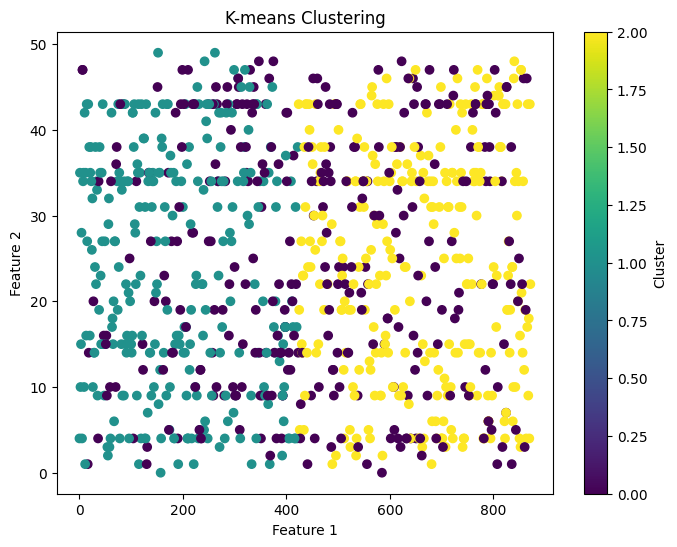

In [135]:
k=3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(df)
labels = kmeans.labels_
df['Cluster'] = labels
silhouette_avg = silhouette_score(df.drop('Cluster', axis=1), labels)
print(f'Silhouette Score: {silhouette_avg}')
plt.figure(figsize=(8, 6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=labels, cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering')
plt.colorbar(label='Cluster')
plt.show()

**DISTRIBUTION - GAUSSIAN NAIVE BAYES**

In [136]:
#Gaussian naive bayes
from sklearn.naive_bayes import GaussianNB

gb = GaussianNB()
gb.fit(x_train,y_train)
y_pred = gb.predict(x_test)

Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       157
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00        19

    accuracy                           0.99       182
   macro avg       0.80      0.80      0.80       182
weighted avg       0.99      0.99      0.99       182


Confusion Matrix:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

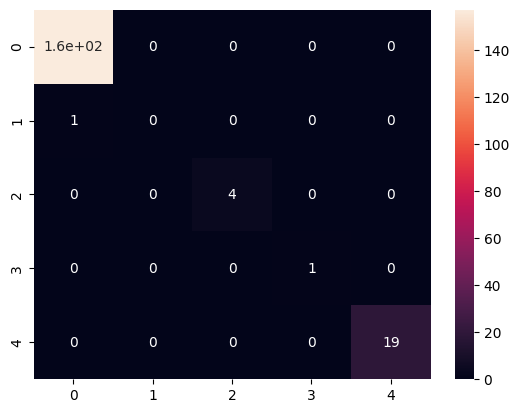

In [137]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))
print('\nConfusion Matrix:')
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

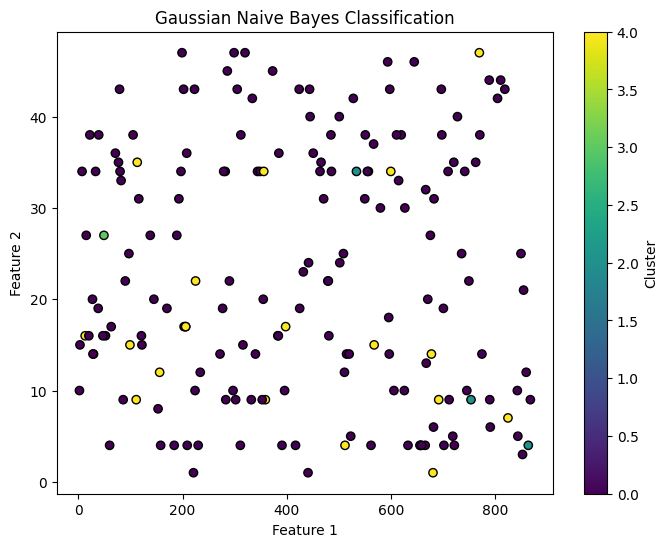

In [138]:
# Visualize the clusters and classification results
plt.figure(figsize=(8, 6))
plt.scatter(x_test.iloc[:, 0], x_test.iloc[:, 1], c=y_pred, cmap='viridis', marker='o', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Gaussian Naive Bayes Classification')
plt.colorbar(label='Cluster')
plt.show()

**HIERARCHICAL - AGNES**

In [139]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
agnes=AgglomerativeClustering(n_clusters=3,affinity='euclidean',linkage='ward')
labels=agnes.fit_predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


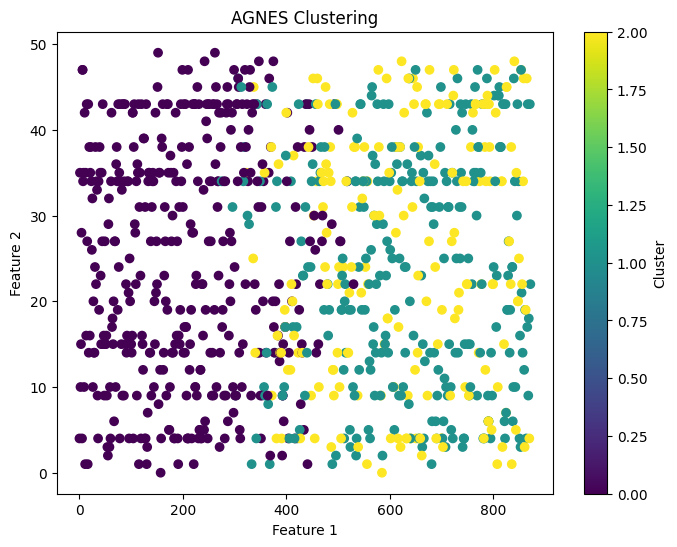

In [140]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('AGNES Clustering')
plt.colorbar(label='Cluster')
plt.show()

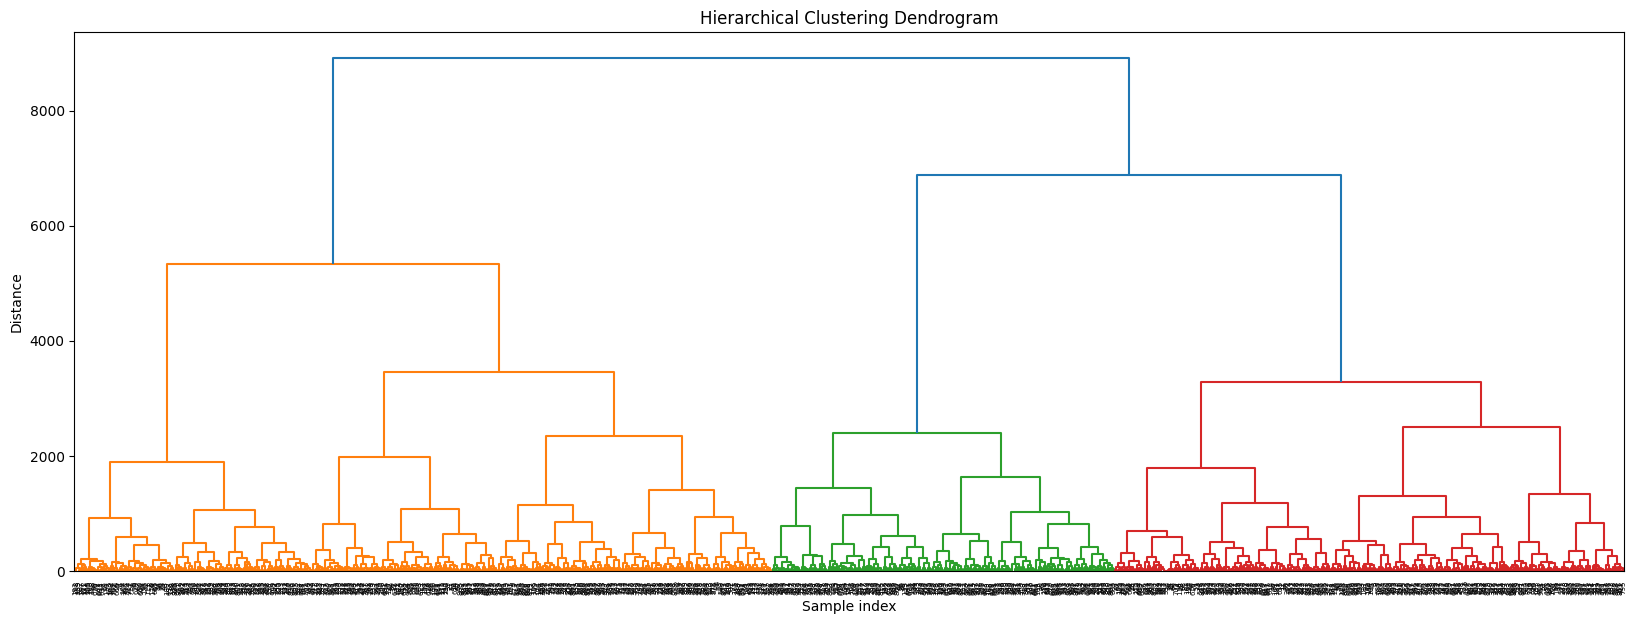

In [141]:
Z = linkage(X, method='ward')
plt.figure(figsize=(20, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.show()

**FUZZY - FUZZY C MEANS**

In [142]:
pip install -U scikit-fuzzy

In [143]:
import skfuzzy as fuzz
c = 3
m = 2
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X.T,c,m,error=0.005,maxiter=1000,init=None)
labels = np.argmax(u, axis=0)

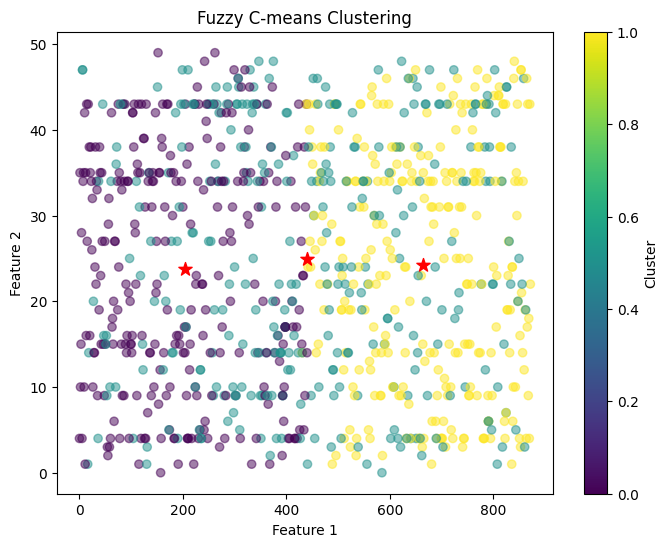

In [144]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', marker='o', alpha=0.5)
plt.scatter(cntr[:, 0], cntr[:, 1], c='red', marker='*', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Fuzzy C-means Clustering')
plt.colorbar(label='Cluster')
plt.show()

**DENSITY - DBSCAN**

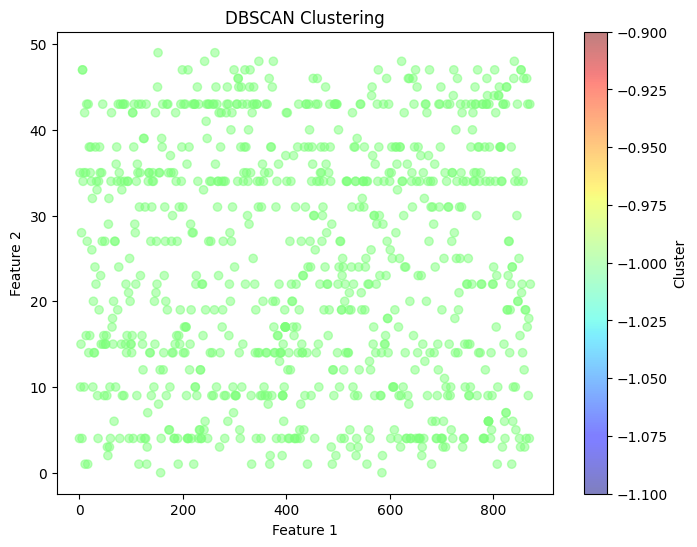

In [145]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.3,min_samples=3)
labels = dbscan.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='jet', marker='o', alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster')
plt.show()

**MODEL CREATIONS**

In [146]:
print(x_train.shape)
print(y_train.shape)

(727, 8)
(727,)


In [147]:
df['Type of Breach'].value_counts()

Type of Breach
0    764
4    116
3     16
2     10
1      3
Name: count, dtype: int64

In [148]:
y_train=keras.utils.to_categorical(y_train,num_classes=5)
y_test=keras.utils.to_categorical(y_test,num_classes=5)

**ATTENTION NEURAL NETWORK**

In [149]:
import tensorflow as tf
from tensorflow.keras import layers

class SelfAttention(layers.Layer):
    def __init__(self, units):
        super(SelfAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, inputs):
        h = self.W1(inputs)
        h = self.W2(h)
        attention_weights = self.V(h)
        attention_weights = tf.keras.activations.softmax(attention_weights, axis=1)
        weighted_inputs = inputs * attention_weights
        weighted_inputs = tf.reduce_sum(weighted_inputs, axis=1)
        return weighted_inputs

model = tf.keras.Sequential([
    layers.Embedding(input_dim=x_train.shape[1], output_dim=64),
    layers.LSTM(64, return_sequences=True),
    SelfAttention(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history=model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))

model.evaluate(x_test, y_test)


Epoch 1/20
23/23 [==============================] - 12s 164ms/step - loss: 1.4553 - accuracy: 0.8006 - val_loss: 0.9994 - val_accuracy: 0.8626
Epoch 2/20
23/23 [==============================] - 1s 42ms/step - loss: 0.6508 - accuracy: 0.8349 - val_loss: 0.5005 - val_accuracy: 0.8626
Epoch 3/20
23/23 [==============================] - 1s 60ms/step - loss: 0.5019 - accuracy: 0.8349 - val_loss: 0.4273 - val_accuracy: 0.8626
Epoch 4/20
23/23 [==============================] - 1s 59ms/step - loss: 0.4309 - accuracy: 0.8349 - val_loss: 0.3741 - val_accuracy: 0.8626
Epoch 5/20
23/23 [==============================] - 2s 90ms/step - loss: 0.3803 - accuracy: 0.8391 - val_loss: 0.3458 - val_accuracy: 0.8681
Epoch 6/20
23/23 [==============================] - 1s 35ms/step - loss: 0.3386 - accuracy: 0.8432 - val_loss: 0.3090 - val_accuracy: 0.8846
Epoch 7/20
23/23 [==============================] - 1s 55ms/step - loss: 0.2769 - accuracy: 0.9161 - val_loss: 0.2409 - val_accuracy: 0.9615
Epoch 8/20


[0.1018495112657547, 0.9725274443626404]

6/6 [==============================] - 0s 4ms/step


<Axes: >

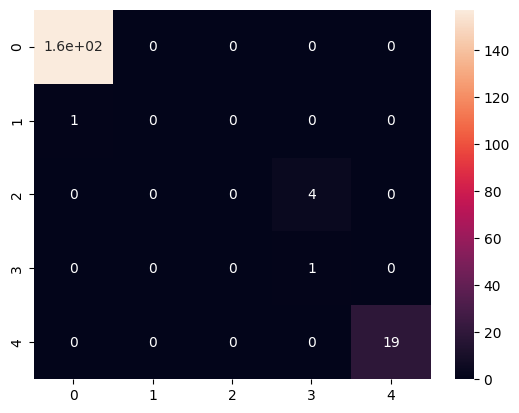

In [150]:
y_pred_prob=model.predict(x_test)
y_pred=np.argmax(y_pred_prob, axis=1)
y_true=np.argmax(y_test, axis=1)
conf_matrix=confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True)

In [151]:
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)
detection_rate_accuracy = {}
for key in report.keys():
    if key.isdigit():
        detection_rate_accuracy[int(key)] = report[key]['recall']
false_alarm_rate = {}
for i in range(conf_matrix.shape[0]):
    false_alarm_rate[i] = conf_matrix.sum(axis=0)[i] - conf_matrix[i, i]

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


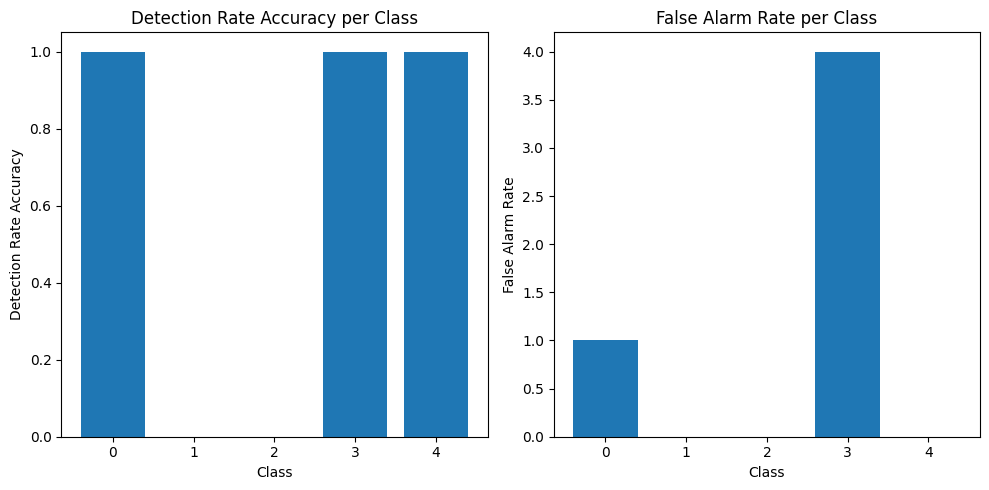

In [152]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(detection_rate_accuracy.keys(), detection_rate_accuracy.values())
plt.xlabel('Class')
plt.ylabel('Detection Rate Accuracy')
plt.title('Detection Rate Accuracy per Class')
plt.subplot(1, 2, 2)
plt.bar(false_alarm_rate.keys(), false_alarm_rate.values())
plt.xlabel('Class')
plt.ylabel('False Alarm Rate')
plt.title('False Alarm Rate per Class')
plt.tight_layout()
plt.show()

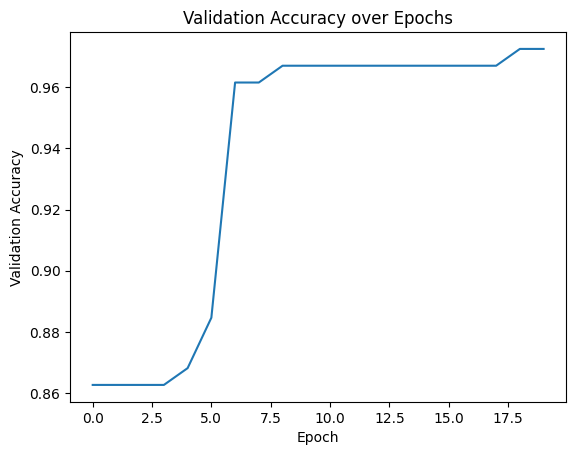

In [153]:
plt.plot(history.history['val_accuracy'])
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()

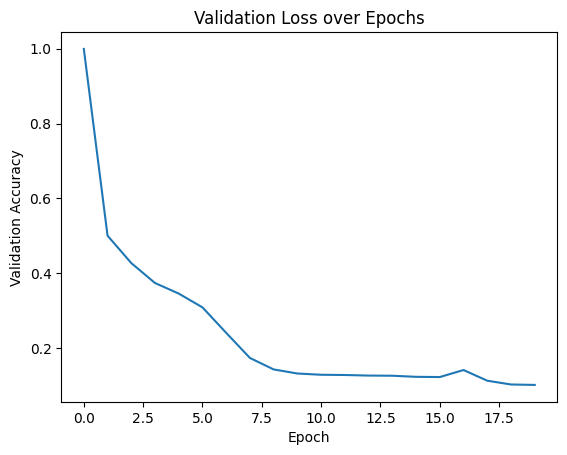

In [154]:
plt.plot(history.history['val_loss'])
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()

**NEURAL NETWORK**

In [166]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input

model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history1 = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))
model.evaluate(x_test, y_test)

Epoch 1/20
23/23 [==============================] - 2s 16ms/step - loss: 14.6533 - accuracy: 0.7029 - val_loss: 4.2465 - val_accuracy: 0.8626
Epoch 2/20
23/23 [==============================] - 0s 7ms/step - loss: 6.9943 - accuracy: 0.7139 - val_loss: 1.4969 - val_accuracy: 0.8626
Epoch 3/20
23/23 [==============================] - 0s 6ms/step - loss: 4.3878 - accuracy: 0.7359 - val_loss: 1.0876 - val_accuracy: 0.8626
Epoch 4/20
23/23 [==============================] - 0s 6ms/step - loss: 3.5131 - accuracy: 0.7455 - val_loss: 0.7583 - val_accuracy: 0.8132
Epoch 5/20
23/23 [==============================] - 0s 6ms/step - loss: 2.8064 - accuracy: 0.7139 - val_loss: 0.6138 - val_accuracy: 0.8626
Epoch 6/20
23/23 [==============================] - 0s 6ms/step - loss: 2.1879 - accuracy: 0.7331 - val_loss: 0.5855 - val_accuracy: 0.8626
Epoch 7/20
23/23 [==============================] - 0s 6ms/step - loss: 1.9966 - accuracy: 0.7538 - val_loss: 0.6026 - val_accuracy: 0.8626
Epoch 8/20
23/23 [

[0.9001893997192383, 0.8626373410224915]

6/6 [==============================] - 0s 4ms/step


<Axes: >

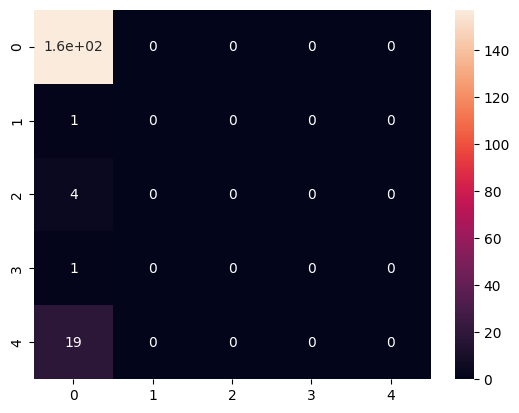

In [167]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


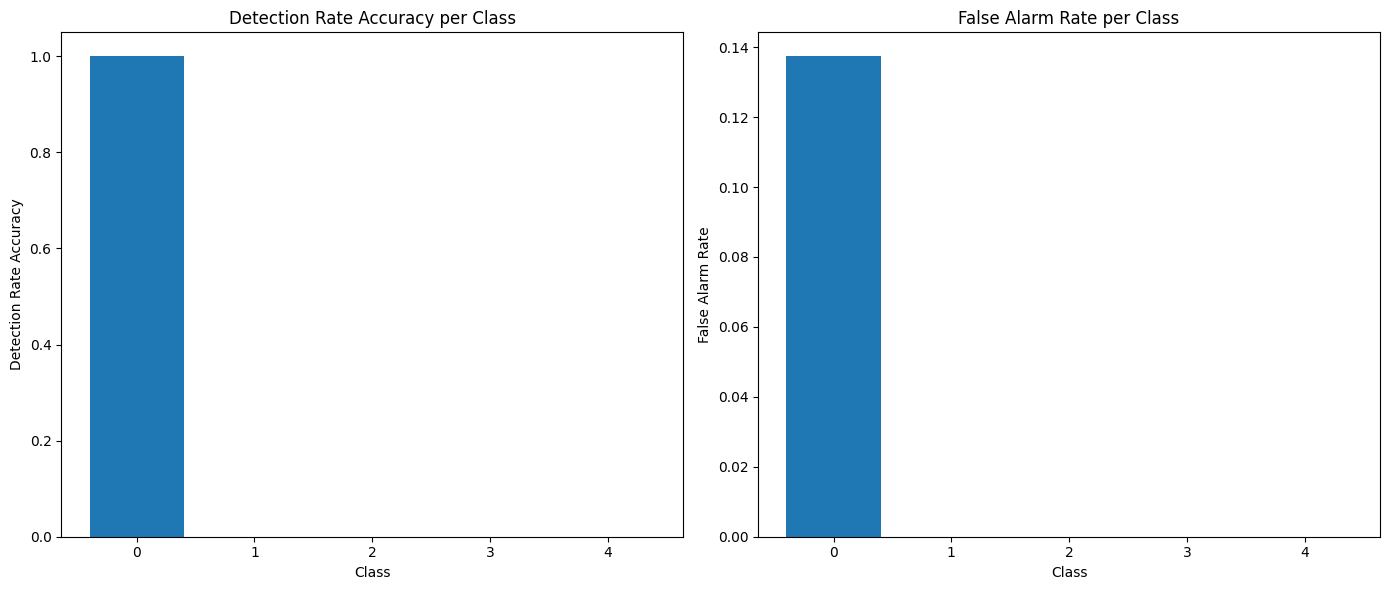

In [168]:
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)

detection_rate_accuracy = {}

for key in report.keys():
    if key.isdigit():
        detection_rate_accuracy[int(key)] = report[key]['recall']
false_alarm_rate = {}

for i in range(conf_matrix.shape[0]):
    false_alarm_rate[i] = (conf_matrix.sum(axis=0)[i] - conf_matrix[i, i]) / conf_matrix.sum()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.bar(detection_rate_accuracy.keys(), detection_rate_accuracy.values())
plt.xlabel('Class')
plt.ylabel('Detection Rate Accuracy')
plt.title('Detection Rate Accuracy per Class')

plt.subplot(1, 2, 2)
plt.bar(false_alarm_rate.keys(), false_alarm_rate.values())
plt.xlabel('Class')
plt.ylabel('False Alarm Rate')
plt.title('False Alarm Rate per Class')

plt.tight_layout()
plt.show()

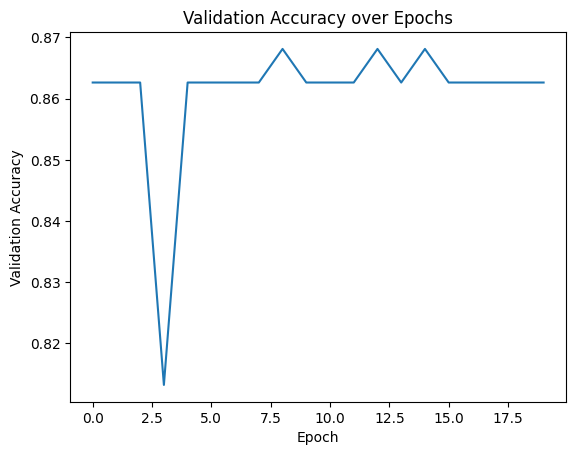

In [169]:
plt.plot(history1.history['val_accuracy'])
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()

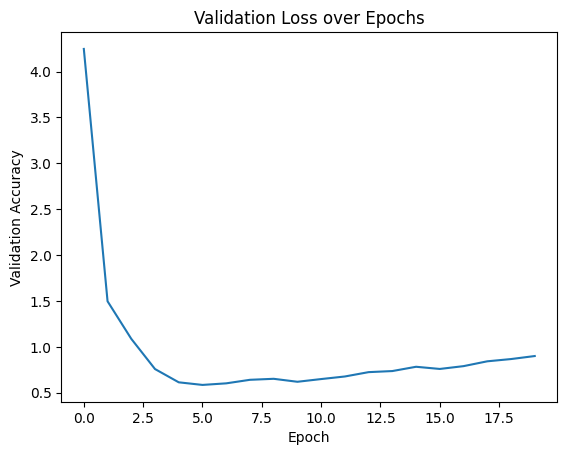

In [170]:
plt.plot(history1.history['val_loss'])
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()

**RNN**

In [171]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Embedding(input_dim=x_train.shape[1], output_dim=64))
model.add(SimpleRNN(64))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history2=model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
model.evaluate(x_test, y_test)

Epoch 1/5
23/23 [==============================] - 6s 173ms/step - loss: 0.9170 - accuracy: 0.7648 - val_loss: 0.4271 - val_accuracy: 0.8626
Epoch 2/5
23/23 [==============================] - 2s 94ms/step - loss: 0.3162 - accuracy: 0.9188 - val_loss: 0.1767 - val_accuracy: 0.9670
Epoch 3/5
23/23 [==============================] - 1s 48ms/step - loss: 0.1270 - accuracy: 0.9697 - val_loss: 0.1027 - val_accuracy: 0.9670
Epoch 4/5
23/23 [==============================] - 1s 22ms/step - loss: 0.0773 - accuracy: 0.9752 - val_loss: 0.0799 - val_accuracy: 0.9670
Epoch 5/5
6/6 [==============================] - 0s 17ms/step - loss: 0.0682 - accuracy: 0.9670


[0.06817952543497086, 0.9670329689979553]

6/6 [==============================] - 0s 4ms/step


<Axes: >

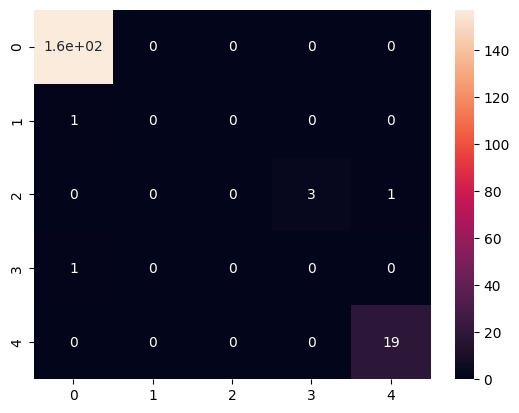

In [172]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


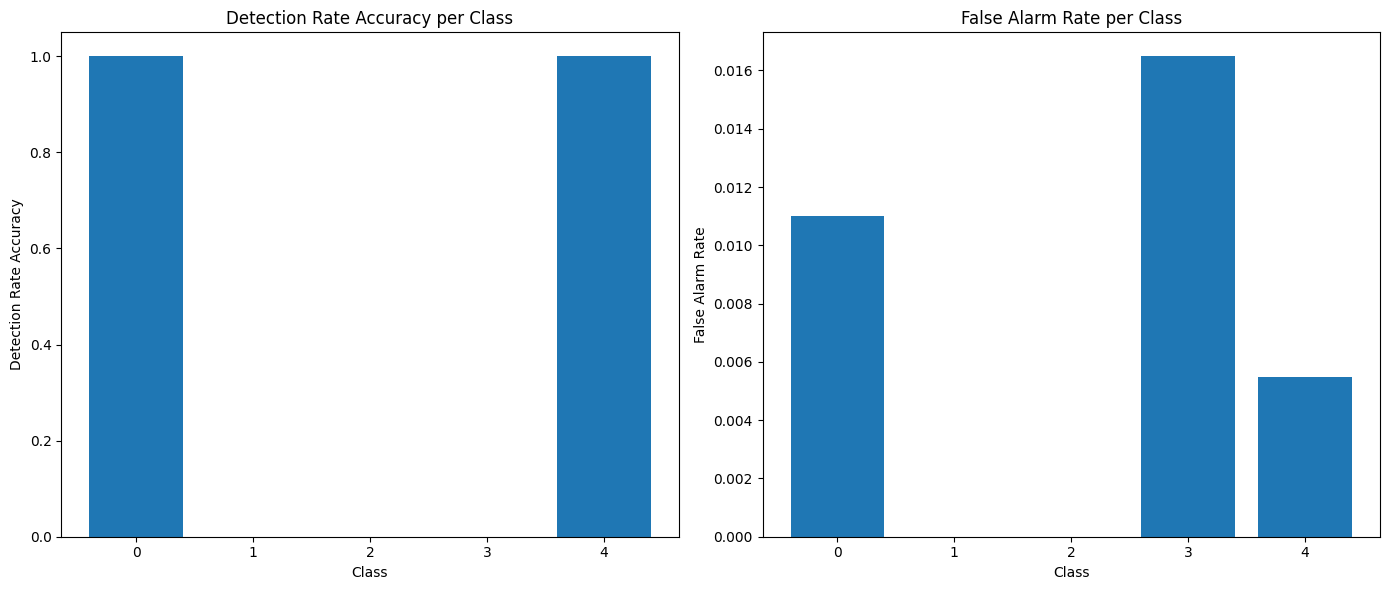

In [173]:
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)

detection_rate_accuracy = {}
for key in report.keys():
    if key.isdigit():
        detection_rate_accuracy[int(key)] = report[key]['recall']

false_alarm_rate = {}
for i in range(conf_matrix.shape[0]):
    false_alarm_rate[i] = (conf_matrix.sum(axis=0)[i] - conf_matrix[i, i]) / conf_matrix.sum(axis=1).sum()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.bar(detection_rate_accuracy.keys(), detection_rate_accuracy.values())
plt.xlabel('Class')
plt.ylabel('Detection Rate Accuracy')
plt.title('Detection Rate Accuracy per Class')

plt.subplot(1, 2, 2)
plt.bar(false_alarm_rate.keys(), false_alarm_rate.values())
plt.xlabel('Class')
plt.ylabel('False Alarm Rate')
plt.title('False Alarm Rate per Class')

plt.tight_layout()
plt.show()

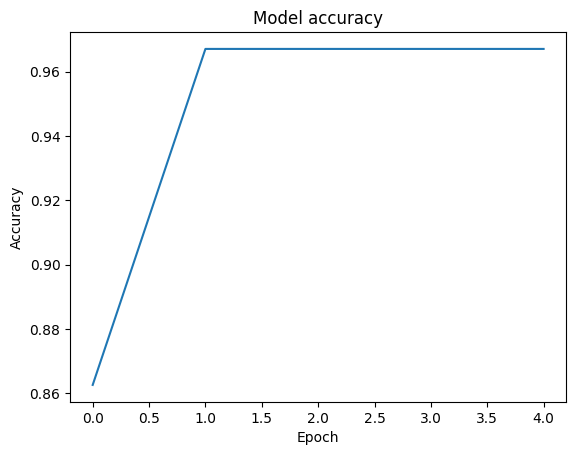

In [174]:
plt.plot(history2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

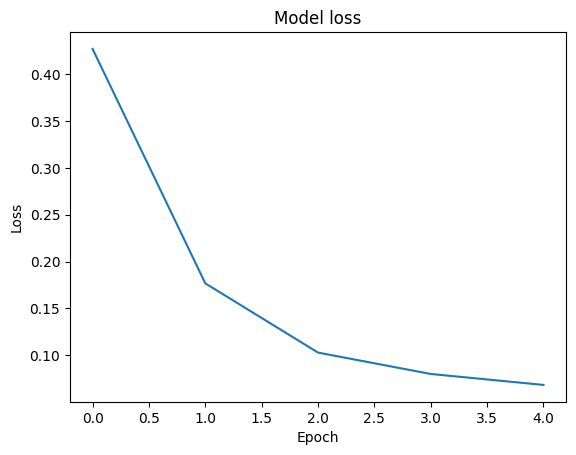

In [175]:
plt.plot(history2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

**DEEP BELIEF NETWORK**

In [162]:
from sklearn.neural_network import BernoulliRBM

rbm1 = BernoulliRBM(n_components=256, learning_rate=0.01, n_iter=10, random_state=42)
rbm2 = BernoulliRBM(n_components=128, learning_rate=0.01, n_iter=10, random_state=42)
rbm1.fit(x_train)
h1_train = rbm1.transform(x_train)
rbm2.fit(h1_train)
h2_train = rbm2.transform(h1_train)

In [176]:
from keras.models import Sequential
from keras.layers import Dense, InputLayer

dbn_model = Sequential()

dbn_model.add(InputLayer(input_shape=(x_train.shape[1],)))

dbn_model.add(Dense(256, activation='relu', weights=[rbm1.components_.T, rbm1.intercept_hidden_]))
dbn_model.add(Dense(128, activation='relu', weights=[rbm2.components_.T, rbm2.intercept_hidden_]))
dbn_model.add(Dense(5, activation='softmax'))
dbn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history3=dbn_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
dbn_model.evaluate(x_test,y_test)

Epoch 1/10
23/23 [==============================] - 2s 22ms/step - loss: 4483187.0000 - accuracy: 0.7139 - val_loss: 2848609.0000 - val_accuracy: 0.8626
Epoch 2/10
23/23 [==============================] - 0s 9ms/step - loss: 1946146.1250 - accuracy: 0.7455 - val_loss: 854162.5625 - val_accuracy: 0.8626
Epoch 3/10
23/23 [==============================] - 0s 7ms/step - loss: 1226412.1250 - accuracy: 0.7387 - val_loss: 2788957.2500 - val_accuracy: 0.1044
Epoch 4/10
23/23 [==============================] - 0s 10ms/step - loss: 2226961.7500 - accuracy: 0.7015 - val_loss: 979547.1875 - val_accuracy: 0.8626
Epoch 5/10
23/23 [==============================] - 0s 11ms/step - loss: 1046030.2500 - accuracy: 0.7387 - val_loss: 731420.5625 - val_accuracy: 0.8626
Epoch 6/10
23/23 [==============================] - 0s 10ms/step - loss: 1006729.9375 - accuracy: 0.7153 - val_loss: 2041888.1250 - val_accuracy: 0.8626
Epoch 7/10
23/23 [==============================] - 0s 8ms/step - loss: 1609328.3750 - 

[555731.75, 0.8626373410224915]

6/6 [==============================] - 0s 3ms/step


<Axes: >

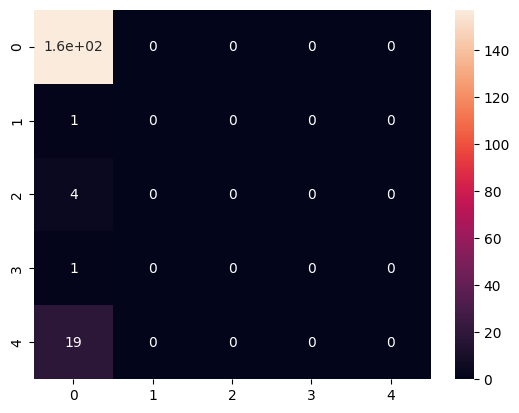

In [177]:
y_pred_prob = dbn_model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


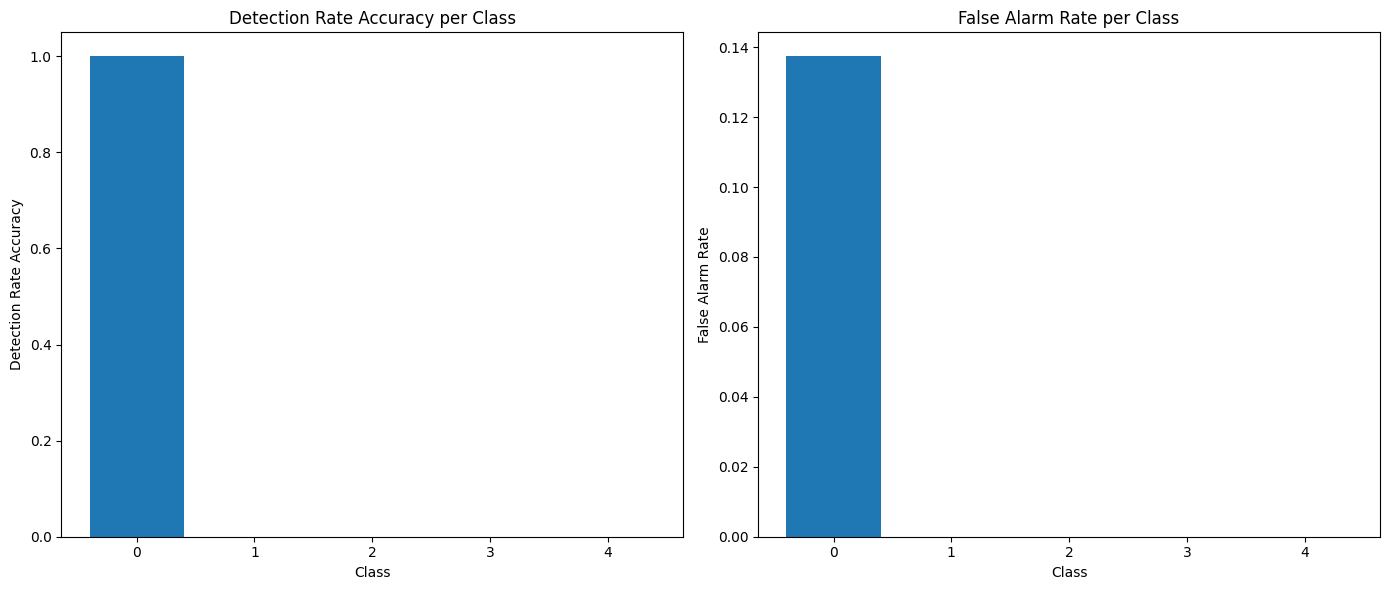

In [178]:
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)

detection_rate_accuracy = {}
for key in report.keys():
    if key.isdigit():
        detection_rate_accuracy[int(key)] = report[key]['recall']

false_alarm_rate = {}
for i in range(conf_matrix.shape[0]):
    false_alarm_rate[i] = (conf_matrix.sum(axis=0)[i] - conf_matrix[i, i]) / conf_matrix.sum(axis=1).sum()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.bar(detection_rate_accuracy.keys(), detection_rate_accuracy.values())
plt.xlabel('Class')
plt.ylabel('Detection Rate Accuracy')
plt.title('Detection Rate Accuracy per Class')

plt.subplot(1, 2, 2)
plt.bar(false_alarm_rate.keys(), false_alarm_rate.values())
plt.xlabel('Class')
plt.ylabel('False Alarm Rate')
plt.title('False Alarm Rate per Class')

plt.tight_layout()
plt.show()

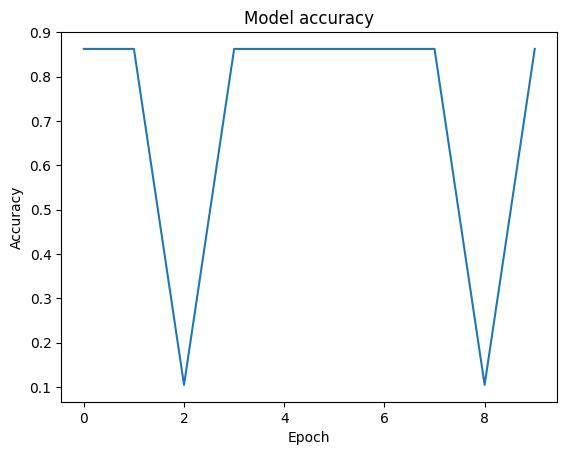

In [179]:
plt.plot(history3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

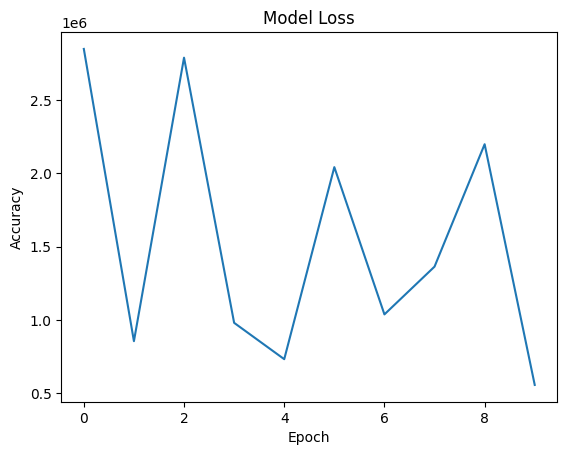

In [180]:
plt.plot(history3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()